In [2]:
import numpy as np
import csv

np.random.seed(42)

num_snps = 1000
num_samples = 200


samples = []
for i in range(num_samples):
    if i < num_samples // 2:
        samples.append(f"healthy_{i}")
    else:
        samples.append(f"dkd_{i}")


snp_info = []
for i in range(num_snps):
    chrom = np.random.randint(1, 5)  # chromosomes 1–4
    pos = np.random.randint(1e6, 1e7)
    snp_id = f"rs{i}"
    allele = "A/G"
    snp_info.append([f"chr{chrom}:{pos}", snp_id, allele])

# -------------------------------
# 3. GENERATE GENOTYPE DATA
# -------------------------------
data = []

for i in range(num_snps):

    # 🔥 Introduce causal SNPs (DKD-associated)
    if i < 25:
        p_healthy = 0.2
        p_dkd = 0.7
    else:
        p_healthy = p_dkd = np.random.uniform(0.1, 0.5)

    # Hardy-Weinberg sampling
    snp_healthy = np.random.choice(
        [0,1,2],
        size=num_samples//2,
        p=[(1-p_healthy)**2, 2*p_healthy*(1-p_healthy), p_healthy**2]
    )

    snp_dkd = np.random.choice(
        [0,1,2],
        size=num_samples//2,
        p=[(1-p_dkd)**2, 2*p_dkd*(1-p_dkd), p_dkd**2]
    )

    snp_values = np.concatenate([snp_healthy, snp_dkd])
    data.append(snp_values)


with open("dkd_gwas_data.csv", "w", newline="") as f:
    writer = csv.writer(f)

    # header
    writer.writerow(["CHR_POS", "SNP_ID", "ALLELES"] + samples)

    # rows
    for i in range(num_snps):
        writer.writerow(snp_info[i] + list(data[i]))

print("DKD dataset generated: dkd_gwas_data.csv")

DKD dataset generated: dkd_gwas_data.csv


In [3]:
import numpy as np
import csv

np.random.seed(42)


num_snps = 1000
N = 200


samples = [f"healthy_{i}" for i in range(N//2)] + \
          [f"dkd_{i}" for i in range(N//2)]


alleles_list = ["A", "T", "C", "G"]
snp_info = []

for i in range(num_snps):
    chrom = np.random.randint(1, 5)
    pos = np.random.randint(1e6, 1e7)


    ref = np.random.choice(alleles_list)
    alt = np.random.choice([a for a in alleles_list if a != ref])

    snp_info.append([f"chr{chrom}:{pos}", f"rs{i}", f"{ref}/{alt}"])


data = []

for i in range(num_snps):


    if i < 20:
        p_healthy = 0.2
        p_dkd = 0.8
    else:
        p_healthy = p_dkd = np.random.uniform(0.1, 0.5)

    snp_healthy = np.random.choice(
        [0,1,2],
        size=N//2,
        p=[(1-p_healthy)**2, 2*p_healthy*(1-p_healthy), p_healthy**2]
    )

    snp_dkd = np.random.choice(
        [0,1,2],
        size=N//2,
        p=[(1-p_dkd)**2, 2*p_dkd*(1-p_dkd), p_dkd**2]
    )

    snp = np.concatenate([snp_healthy, snp_dkd])
    data.append(snp)


with open("dkd_dataset_realistic.csv", "w", newline="") as f:
    writer = csv.writer(f)

    writer.writerow(["CHR_POS", "SNP_ID", "ALLELES"] + samples)

    for i in range(num_snps):
        writer.writerow(snp_info[i] + list(data[i]))

print("Realistic DKD dataset created!")

Realistic DKD dataset created!


READ THE DATA

In [4]:
import csv
import numpy as np

snp_info = []
data = []

with open("dkd_dataset_realistic.csv") as csvfile:
    reader = csv.reader(csvfile)

    for row in reader:
        snp_info.append(row[0:3])
        data.append(row[3:])

SEPARATE HEADER

In [5]:
snp_header = snp_info[0]
snp_info = snp_info[1:]

samples = data[0]
data = data[1:]

Convert to numpy

In [6]:
snp_info = np.array(snp_info)
data = np.array(data).astype(int)

samples = np.array(samples)

EXTRACT LABELS

In [7]:
labels = []

for s in samples:
    labels.append(s.split("_")[0])

labels = np.array(labels)

ENCODE LABELS

In [8]:
encoded_labels = np.where(labels == "dkd", 1, 0)

MAF FILTER

In [9]:
maf_threshold = 0.05
total_alleles = len(samples) * 2

to_keep = []

for i in range(data.shape[0]):

    ref_count = 2*np.sum(data[i]==0) + np.sum(data[i]==1)
    alt_count = 2*np.sum(data[i]==2) + np.sum(data[i]==1)

    maf = min(ref_count, alt_count) / total_alleles

    to_keep.append(maf >= maf_threshold)

to_keep = np.array(to_keep)

filtered_data = data[to_keep]
filtered_snp_info = snp_info[to_keep]

GWAS

In [10]:
import statsmodels.api as sm

p_values = []

for i in range(filtered_data.shape[0]):

    snp = filtered_data[i]

    X = sm.add_constant(snp.astype(float))
    result = sm.Logit(encoded_labels, X).fit(disp=False)

    if result.mle_retvals["converged"]:
        p_values.append(result.pvalues[1])
    else:
        p_values.append(1.0)

p_values = np.array(p_values)

In [11]:
p_values_bonf = p_values * len(p_values)

In [12]:
significant_snps = filtered_snp_info[p_values_bonf <= 0.05]

print(significant_snps)

[['chr3:7423388' 'rs0' 'C/G']
 ['chr4:5304572' 'rs1' 'A/G']
 ['chr2:8204212' 'rs2' 'G/C']
 ['chr2:8404852' 'rs3' 'T/C']
 ['chr2:4344769' 'rs4' 'G/A']
 ['chr1:6664789' 'rs5' 'A/T']
 ['chr1:6743066' 'rs6' 'C/G']
 ['chr2:5721339' 'rs7' 'G/C']
 ['chr2:4275709' 'rs8' 'C/T']
 ['chr3:9242680' 'rs9' 'C/A']
 ['chr3:3663046' 'rs10' 'A/T']
 ['chr3:7640913' 'rs11' 'G/A']
 ['chr4:4385357' 'rs12' 'T/C']
 ['chr1:2465689' 'rs13' 'A/C']
 ['chr4:5056518' 'rs14' 'G/A']
 ['chr4:7397986' 'rs15' 'T/A']
 ['chr4:7249859' 'rs16' 'T/C']
 ['chr2:4910197' 'rs17' 'T/C']
 ['chr1:4584702' 'rs18' 'T/C']
 ['chr4:9585377' 'rs19' 'T/C']]


In [13]:
filtered_snp_chromosomes = []
filtered_snp_positions = []

for snp in filtered_snp_info[:,0]:
    chrom, pos = snp.split(":")
    chrom = int(chrom.replace("chr",""))
    pos = int(pos)

    filtered_snp_chromosomes.append(chrom)
    filtered_snp_positions.append(pos)

filtered_snp_chromosomes = np.array(filtered_snp_chromosomes)
filtered_snp_positions = np.array(filtered_snp_positions)

In [14]:
neg_log_p_values = -np.log10(p_values)

In [16]:
import matplotlib.pyplot as plt


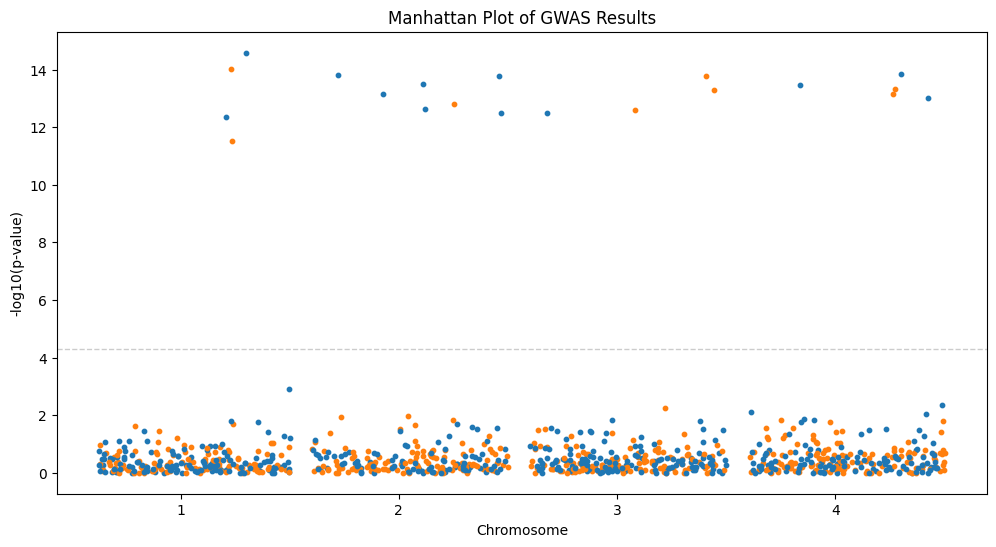

In [18]:

snp_data = np.column_stack((filtered_snp_chromosomes, filtered_snp_positions, neg_log_p_values))


snp_data = snp_data[np.lexsort((snp_data[:, 1], snp_data[:, 0]))]


cumulative_positions = np.zeros_like(filtered_snp_positions)
chromosome_offsets = {}
midpoints = []

current_offset = 0
for chromosome in np.unique(filtered_snp_chromosomes):
    chrom_mask = filtered_snp_chromosomes == chromosome
    chromosome_offsets[chromosome] = current_offset
    cumulative_positions[chrom_mask] = filtered_snp_positions[chrom_mask] + current_offset
    midpoints.append((current_offset + np.max(cumulative_positions[chrom_mask])) / 2)
    current_offset += np.max(filtered_snp_positions[chrom_mask]) + 1


plt.figure(figsize=(12, 6))


colors = ['#1f77b4', '#ff7f0e']

dot_size = 10
current_chromosome = 1
for chromosome in np.unique(snp_data[:, 0]):
    chrom_mask = snp_data[:, 0] == chromosome
    plt.scatter(cumulative_positions[chrom_mask], snp_data[chrom_mask, 2], c=colors[current_chromosome % 2], s=dot_size, label=f'Chromosome {chromosome}')
    current_chromosome += 1


plt.xticks(midpoints, np.unique(filtered_snp_chromosomes))


sig_thresh = -np.log10(0.05/filtered_data.shape[0])
plt.axhline(y=sig_thresh,
            color='grey',
            linestyle='--',
            linewidth=1,
            alpha=0.4)

# Add labels and title
plt.xlabel('Chromosome')
plt.ylabel('-log10(p-value)')
plt.title('Manhattan Plot of GWAS Results')
# plt.legend()

# Show the plot


plt.show()

In [19]:
sig_mask = p_values_bonf <= 0.05

In [20]:
sig_snp_info = filtered_snp_info[sig_mask]
sig_pvals = p_values[sig_mask]
sig_neglog = -np.log10(sig_pvals)

In [21]:
import pandas as pd

sig_df = pd.DataFrame({
    "SNP_ID": sig_snp_info[:,0],
    "Alleles": sig_snp_info[:,2],
    "p_value": sig_pvals,
    "-log10(p)": sig_neglog
})

In [22]:
sig_df = sig_df.sort_values(by="p_value")

In [23]:
print(sig_df.head(10))

          SNP_ID Alleles       p_value  -log10(p)
16  chr4:7249859     T/C  2.586668e-15  14.587259
13  chr1:2465689     A/C  9.391639e-15  14.027259
12  chr4:4385357     T/C  1.426676e-14  13.845675
19  chr4:9585377     T/C  1.523302e-14  13.817214
18  chr1:4584702     T/C  1.670978e-14  13.777029
7   chr2:5721339     G/C  1.698682e-14  13.769888
2   chr2:8204212     G/C  3.125833e-14  13.505034
3   chr2:8404852     T/C  3.513157e-14  13.454302
0   chr3:7423388     C/G  4.736178e-14  13.324572
6   chr1:6743066     C/G  5.127845e-14  13.290065
